In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [2]:
image = cv2.imread('vid.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

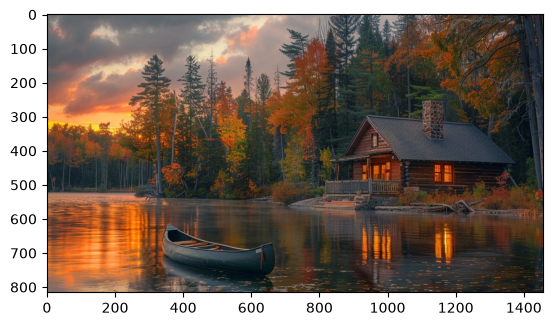

In [3]:
plt.imshow(image)

In [4]:
image.shape # h,w,c

(816, 1456, 3)

In [5]:
image[250,250] # b,g,r

array([100,  74,  57], dtype=uint8)

In [6]:
# ROI
img_roi = image[100:200, 500:700]

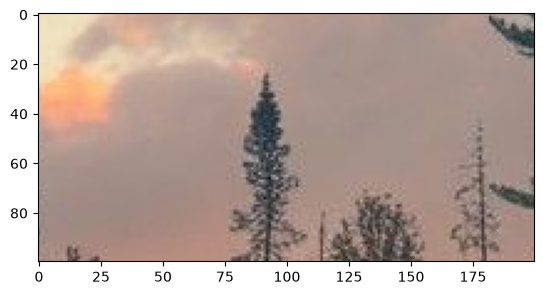

In [7]:
plt.imshow(img_roi)

In [8]:
b,g,r = cv2.split(image)

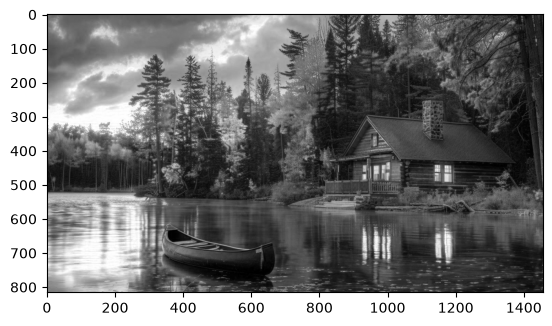

In [9]:
plt.imshow(b, cmap = 'gray')

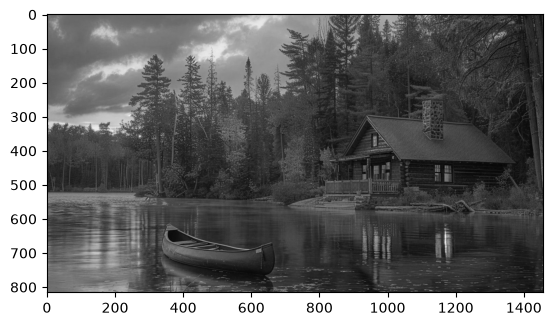

In [10]:
plt.imshow(g, cmap = 'gray')

In [11]:
# alternative approach
b = image[:,:,0]

In [12]:
import copy

image2 = copy.deepcopy(image)

In [13]:
image2[50:100,50:100] = [0,0,0]

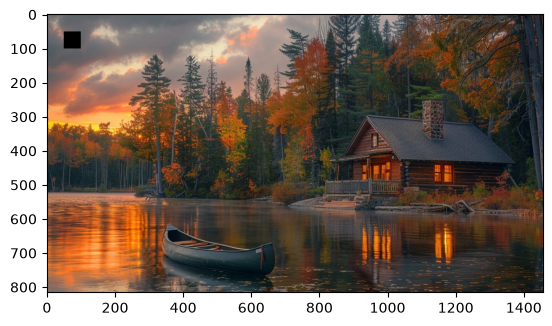

In [14]:
plt.imshow(image2)

In [15]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

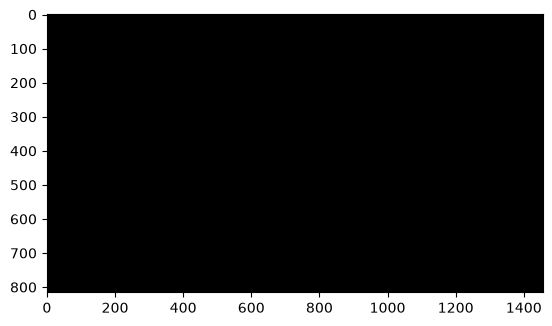

In [16]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [17]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [18]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [19]:
image_gray[0,0]

np.uint8(109)

In [20]:
image_gray.shape

(816, 1456)

In [21]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [22]:
image_hsv.shape

(816, 1456, 3)

In [23]:
image_hsv[0,0]

array([135,   5, 110], dtype=uint8)

In [24]:
image[0,0]

array([110, 108, 109], dtype=uint8)

In [25]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [26]:
image_lab[0,0]

array([117, 129, 127], dtype=uint8)

# Пороговая фильтрация

In [27]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

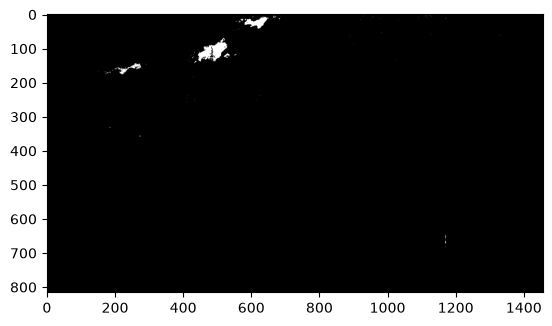

In [28]:
plt.imshow(thresh1, cmap='gray')

In [29]:
thresh1[thresh1==100].sum()

np.uint64(0)

# Построение гистограммы

In [30]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

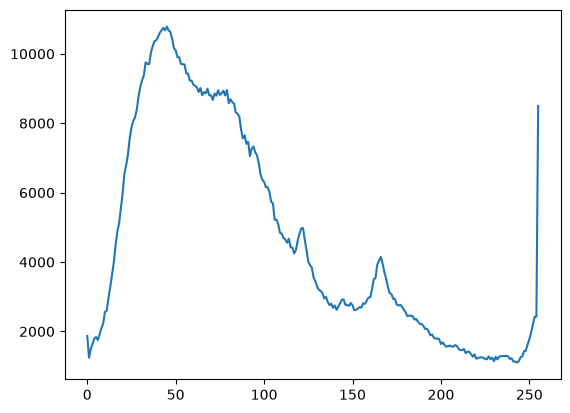

In [31]:
plt.plot(b_hist)

In [32]:
b_hist_cum = b_hist.cumsum()

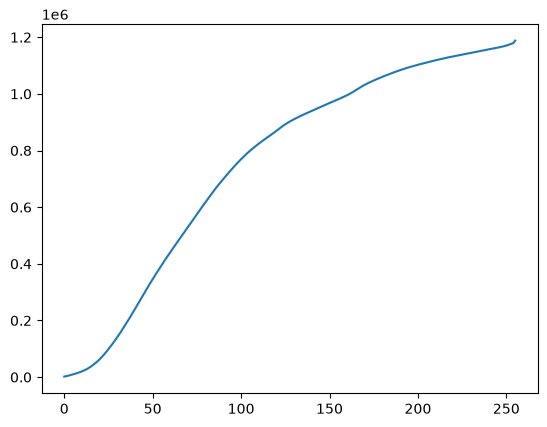

In [33]:
plt.plot(b_hist_cum)

In [34]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

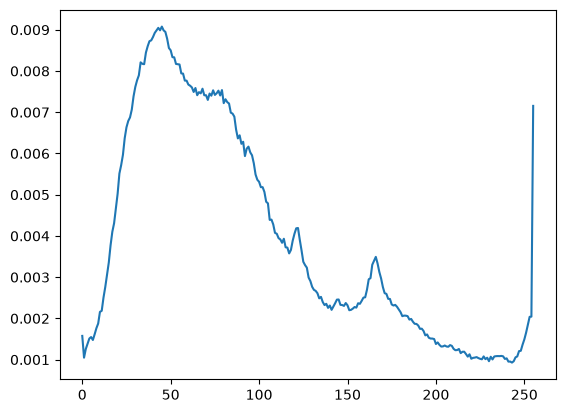

In [35]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [36]:
from skimage.metrics import structural_similarity, mean_squared_error

image2_gray = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
(ssim, diff) = structural_similarity(image_gray, image2_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 0.9973620223212589


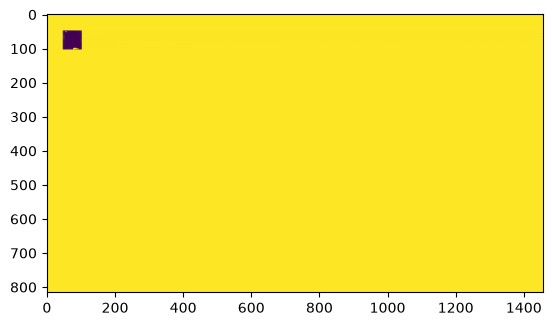

In [37]:
plt.imshow(diff)

In [38]:
mse = mean_squared_error(image_gray, image_gray)
mse

np.float64(0.0)

# Статистические характеристики изображений

In [39]:
mean = image_gray.mean()

In [40]:
std = image_gray.std()

In [41]:
print(mean,std)

70.67352890675501 39.366428392152656


In [42]:
eq_gray = cv2.equalizeHist(image_gray)

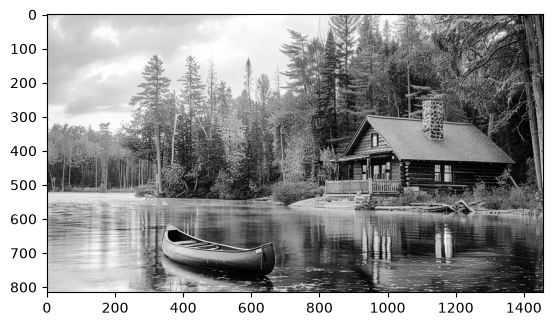

In [43]:
plt.imshow(eq_gray, cmap="gray")


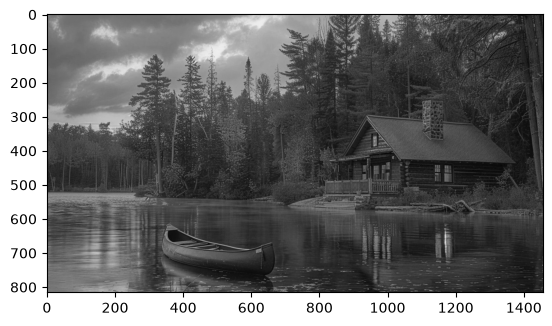

In [44]:
plt.imshow(image_gray, cmap="gray")

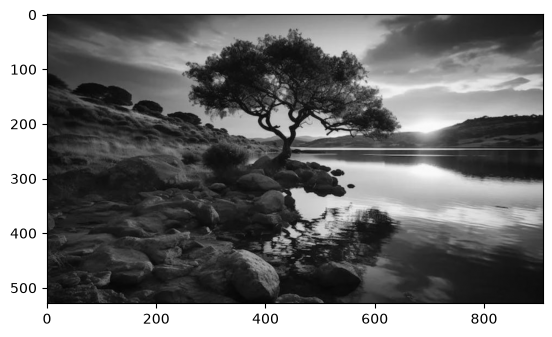

In [45]:
# Задание 1
sar_1_gray_dz = cv2.imread('vid_gray.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(sar_1_gray_dz, cmap='gray')

In [46]:
sar_1_gray_dz.shape

(529, 908)

In [47]:
# Задание 2
histSize = 256
histRange = (0, 256)
accumulate = False

gray_hist_dz = cv2.calcHist([sar_1_gray_dz], [0], None, [histSize], histRange, accumulate=accumulate)

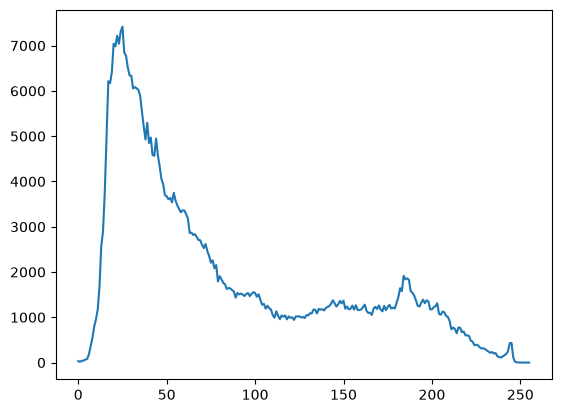

In [48]:
plt.plot(gray_hist_dz)

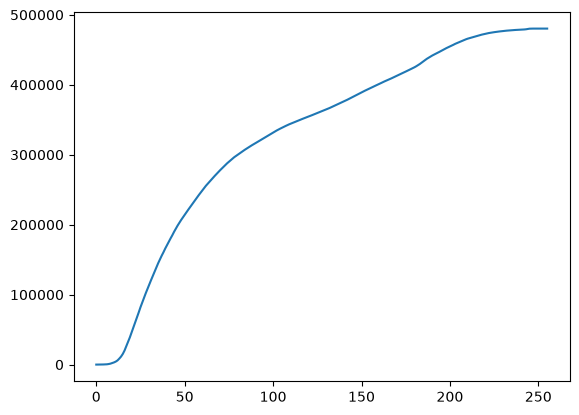

In [49]:
gray_hist_dz_cum = gray_hist_dz.cumsum()
plt.plot(gray_hist_dz_cum)

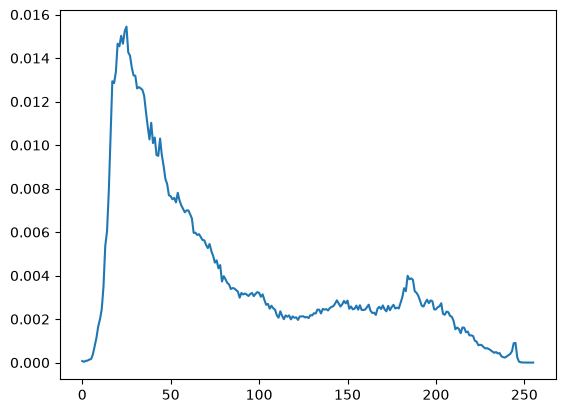

In [50]:
gray_hist_dz_norm = gray_hist_dz / (sar_1_gray_dz.shape[0] * sar_1_gray_dz.shape[1])
plt.plot(gray_hist_dz_norm)

In [51]:
# Задание 3
def gamma_correction(image, gamma):
    table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(image, table)

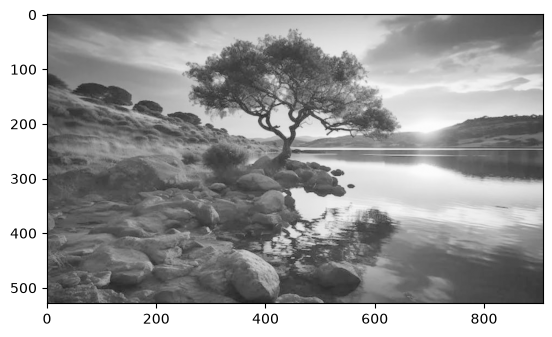

In [52]:
# gamma < 1
image_gamma_low_dz = gamma_correction(sar_1_gray_dz, 0.5)
plt.imshow(image_gamma_low_dz, cmap='gray')

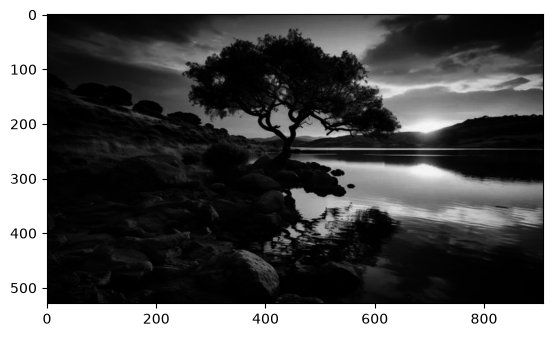

In [53]:
# gamma > 1
image_gamma_high_dz = gamma_correction(sar_1_gray_dz, 2.0)
plt.imshow(image_gamma_high_dz, cmap='gray')

In [54]:
# Задание 4
from skimage.metrics import structural_similarity, mean_squared_error

In [55]:
# gamma < 1
(ssim_low_dz, diff_low_dz) = structural_similarity(sar_1_gray_dz, image_gamma_low_dz, full=True, data_range=255)
diff_low_dz = np.clip((1 - diff_low_dz) * 255, 0, 255).astype("uint8")
print("SSIM (gamma<1): {}".format(ssim_low_dz))

SSIM (gamma<1): 0.7610081745913351


In [56]:
mse_low_dz = mean_squared_error(sar_1_gray_dz, image_gamma_low_dz)
mse_low_dz

np.float64(2858.336635910162)

In [57]:
# gamma > 1
(ssim_high_dz, diff_high_dz) = structural_similarity(sar_1_gray_dz, image_gamma_high_dz, full=True, data_range=255)
diff_high_dz = np.clip((1 - diff_high_dz) * 255, 0, 255).astype("uint8")
print("SSIM (gamma>1): {}".format(ssim_high_dz))

SSIM (gamma>1): 0.4774311171516444


In [58]:
mse_high_dz = mean_squared_error(sar_1_gray_dz, image_gamma_high_dz)
mse_high_dz

np.float64(1928.4434391212744)

In [59]:
print(f"SSIM (gamma < 1): {ssim_low_dz:.4f}, MSE: {mse_low_dz:.2f}")
print(f"SSIM (gamma > 1): {ssim_high_dz:.4f}, MSE: {mse_high_dz:.2f}")

SSIM (gamma < 1): 0.7610, MSE: 2858.34
SSIM (gamma > 1): 0.4774, MSE: 1928.44


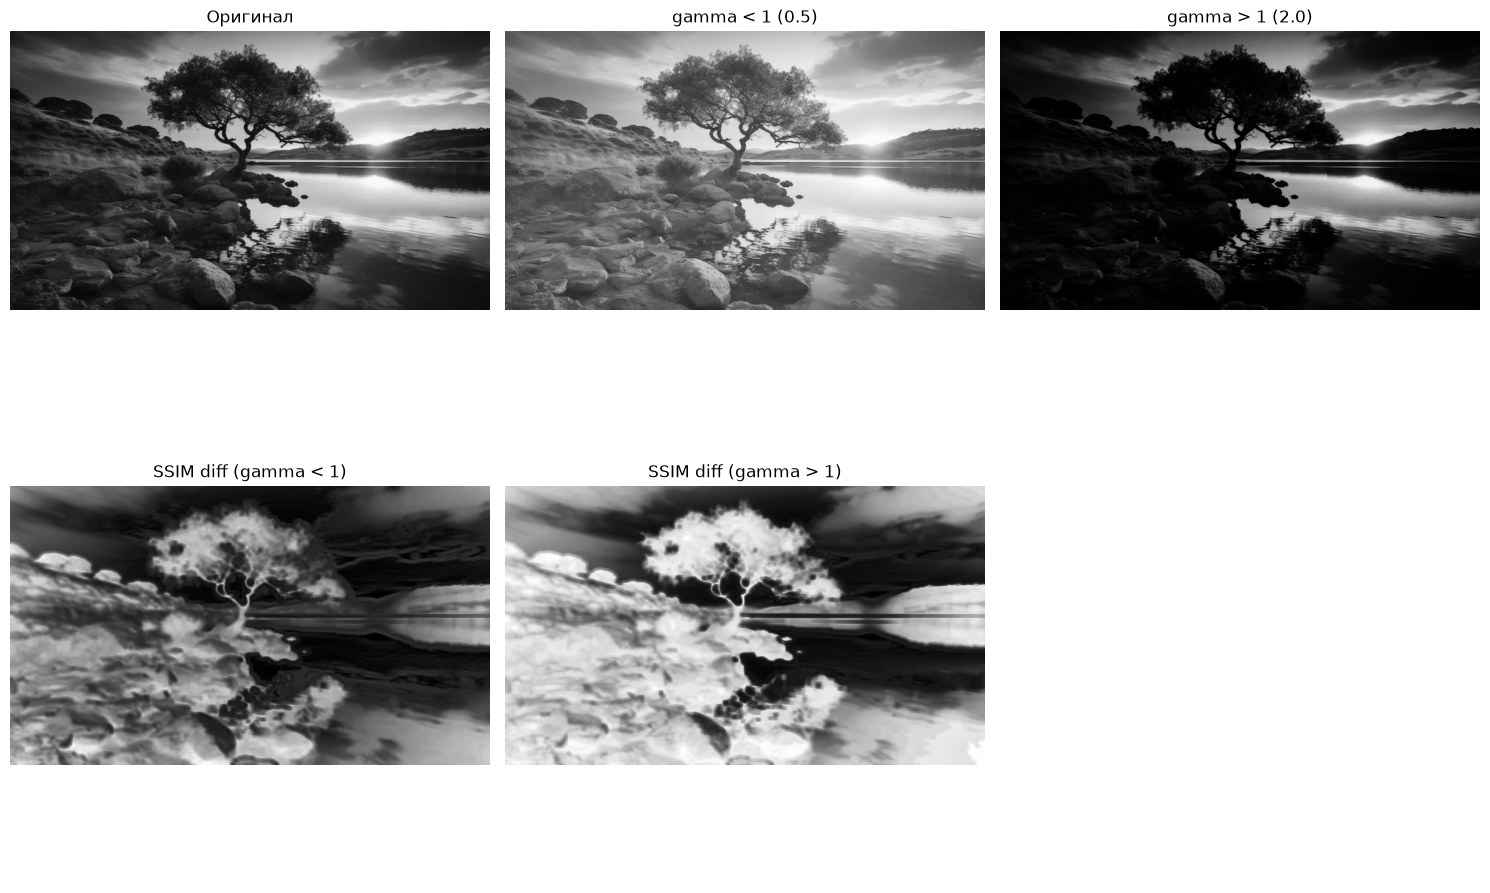

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(sar_1_gray_dz, cmap='gray')
axes[0, 0].set_title('Оригинал')

axes[0, 1].imshow(image_gamma_low_dz, cmap='gray')
axes[0, 1].set_title('gamma < 1 (0.5)')

axes[0, 2].imshow(image_gamma_high_dz, cmap='gray')
axes[0, 2].set_title('gamma > 1 (2.0)')

axes[1, 0].imshow(diff_low_dz, cmap='gray')
axes[1, 0].set_title('SSIM diff (gamma < 1)')

axes[1, 1].imshow(diff_high_dz, cmap='gray')
axes[1, 1].set_title('SSIM diff (gamma > 1)')

axes[1, 2].axis('off')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [61]:
# Задание 5
eq_gray.mean(), eq_gray.std()

(np.float64(128.6981481294441), np.float64(73.19570759715968))

In [62]:
sar_1_gray_dz.mean(), sar_1_gray_dz.std()

(np.float64(81.37849862178659), np.float64(61.60014935096285))

In [63]:
def match_statistics(src, ref):
    src = src.astype(np.float32)
    ref = ref.astype(np.float32)
    out = (src - src.mean()) * (ref.std() / (src.std() + 1e-8)) + ref.mean()
    return np.clip(out, 0, 255).astype(np.uint8)

In [64]:
stat_corrected_dz = match_statistics(sar_1_gray_dz, eq_gray)
stat_corrected_dz.mean(), stat_corrected_dz.std()

(np.float64(126.2176640323776), np.float64(69.13428210362865))

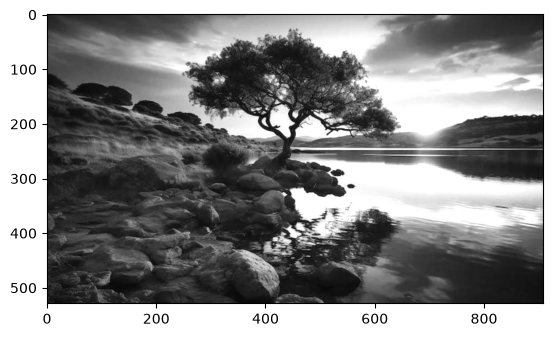

In [65]:
plt.imshow(stat_corrected_dz, cmap='gray')

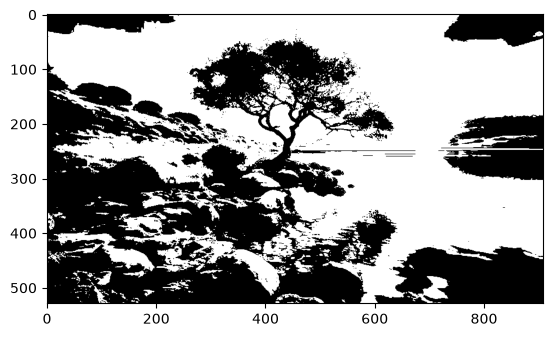

In [66]:
# Задание 6 
_, thresh_50_dz = cv2.threshold(sar_1_gray_dz, 50, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_50_dz, cmap='gray')

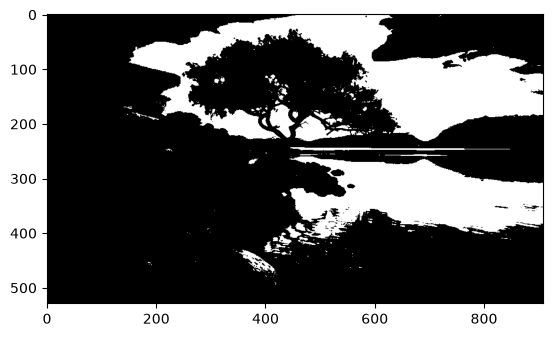

In [67]:
_, thresh_127_dz = cv2.threshold(sar_1_gray_dz, 127, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_127_dz, cmap='gray')

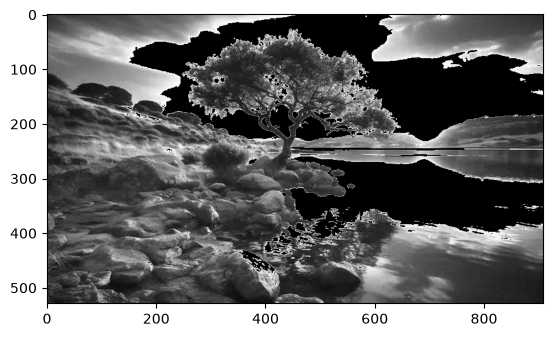

In [68]:
_, thresh_tozero_inv_dz = cv2.threshold(sar_1_gray_dz, 127, 255, cv2.THRESH_TOZERO_INV)
plt.imshow(thresh_tozero_inv_dz, cmap='gray')

In [69]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. +
# 2. постройте гистограмму +
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1. +
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM. +
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray. +
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами. +
# Для каждого решения - напечатайте результат +
